<a href="https://colab.research.google.com/github/ludmila-sla/aulas-mestrado/blob/main/atividadeCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)


train_size = int(0.9 * len(train_data))
val_size = len(train_data) - train_size

train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [07:37<00:00, 373kB/s]


In [ ]:
class CNN(nn.Module):
    def __init__(self, conv_layers, fc_layers, dropout=0.0):
        super(CNN, self).__init__()

        layers = []
        in_channels = 3

        for out_channels in conv_layers:
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            in_channels = out_channels

        self.conv = nn.Sequential(*layers)


        dummy = torch.zeros(1, 3, 32, 32)
        conv_out_size = self.conv(dummy).view(1, -1).size(1)

        fc = []
        in_features = conv_out_size

        for units in fc_layers:
            fc.append(nn.Linear(in_features, units))
            fc.append(nn.ReLU())
            if dropout > 0:
                fc.append(nn.Dropout(dropout))
            in_features = units

        fc.append(nn.Linear(in_features, 10))

        self.fc = nn.Sequential(*fc)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
def train_model(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float('inf')
    patience = 3
    trigger = 0

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(total_loss / len(train_loader))
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1} | Train Loss: {total_loss:.3f} | Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.2f}%")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger = 0
        else:
            trigger += 1
            if trigger >= patience:
                print("Early stopping!")
                break

    return history

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    return loss_total / len(loader), acc

In [ ]:
models_config = {
    "CNN_1": {"conv": [32, 64], "fc": [128], "dropout": 0.0},
    "CNN_2": {"conv": [32, 64, 128], "fc": [256, 128], "dropout": 0.1},
    "CNN_3": {"conv": [64, 128, 128, 256], "fc": [256, 128], "dropout": 0.3}
}

In [ ]:
results = {}

for name, config in models_config.items():
    print(f"\nTreinando {name}")

    model = CNN(config["conv"], config["fc"], config["dropout"]).to(device)
    history = train_model(model, train_loader, val_loader)

    test_loss, test_acc = evaluate(model, test_loader)

    results[name] = {
        "history": history,
        "test_acc": test_acc
    }

    print(f"{name} Test Accuracy: {test_acc:.2f}%")


Treinando CNN_1
Epoch 1 | Train Loss: 1102.486 | Val Loss: 1.400 | Val Acc: 49.24%
Epoch 2 | Train Loss: 866.511 | Val Loss: 1.174 | Val Acc: 57.32%
Epoch 3 | Train Loss: 768.087 | Val Loss: 1.131 | Val Acc: 59.30%
Epoch 4 | Train Loss: 717.450 | Val Loss: 0.988 | Val Acc: 64.56%
Epoch 5 | Train Loss: 674.231 | Val Loss: 0.946 | Val Acc: 66.58%
Epoch 6 | Train Loss: 639.810 | Val Loss: 0.945 | Val Acc: 66.58%
Epoch 7 | Train Loss: 619.580 | Val Loss: 0.892 | Val Acc: 68.40%
Epoch 8 | Train Loss: 594.649 | Val Loss: 0.872 | Val Acc: 69.08%
Epoch 9 | Train Loss: 576.985 | Val Loss: 0.859 | Val Acc: 69.72%
Epoch 10 | Train Loss: 564.527 | Val Loss: 0.834 | Val Acc: 69.98%
Epoch 11 | Train Loss: 547.921 | Val Loss: 0.801 | Val Acc: 71.58%
Epoch 12 | Train Loss: 536.249 | Val Loss: 0.801 | Val Acc: 71.56%
Epoch 13 | Train Loss: 529.627 | Val Loss: 0.824 | Val Acc: 70.94%
Epoch 14 | Train Loss: 515.475 | Val Loss: 0.764 | Val Acc: 72.70%
Epoch 15 | Train Loss: 509.711 | Val Loss: 0.757 | Va

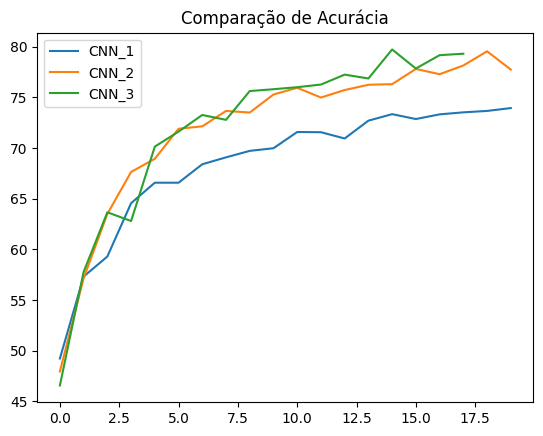

In [ ]:
for name in results:
    plt.plot(results[name]["history"]["val_acc"], label=name)

plt.title("Comparação de Acurácia")
plt.legend()
plt.show()